In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv("../data/processed/dataset.csv", parse_dates=["date"])

In [4]:
df

,date,mean_phy,target,mean_temp,mean_schmidt,mean_par,windspeed_mean,precipitation_tot,month_sin,month_cos
0,2020-07-01,4.796831,0,19.937151,1104.423806,46.780634,2.2,14.0,-5.000000e-01,-0.866025
1,2020-07-02,5.124668,0,19.908480,1113.749434,30.785148,2.0,1.5,-5.000000e-01,-0.866025
2,2020-07-03,5.369718,0,20.055217,1088.947094,10.567077,1.2,0.1,-5.000000e-01,-0.866025
3,2020-07-04,5.676056,0,19.752676,1054.977100,32.419718,1.6,0.0,-5.000000e-01,-0.866025
4,2020-07-05,5.465845,0,19.773824,1064.755147,37.176408,2.4,0.0,-5.000000e-01,-0.866025
...,...,...,...,...,...,...,...,...,...,...
501,2021-12-27,0.365493,0,5.832215,0.370027,-1.668662,1.2,4.8,-2.449294e-16,1.000000
502,2021-12-28,0.220775,0,5.817972,0.028860,-2.277113,5.6,7.3,-2.449294e-16,1.000000
503,2021-12-29,0.165141,0,5.816250,0.300706,-3.384155,4.8,8.3,-2.449294e-16,1.000000
504,2021-12-30,0.602113,0,5.897768,1.447501,-1.472535,1.9,0.0,-2.449294e-16,1.000000


In [5]:
df.groupby(df["date"].dt.month)["mean_phy"].mean()

date
1     3.220866
2     9.258648
3     8.101360
4     9.206293
5     2.868954
6     2.327938
7     5.344140
8     5.544634
9     6.527464
10    8.824125
11    7.312327
12    2.312925
Name: mean_phy, dtype: float64

In [6]:
df.groupby("target")[["mean_temp", "mean_schmidt", "mean_par", "windspeed_mean"]].mean()

,mean_temp,mean_schmidt,mean_par,windspeed_mean
target,,,,
0,14.144389,556.072294,9.152513,1.946966
1,11.207590,297.144333,4.245481,1.703937


In [7]:
features = ["mean_temp", "mean_schmidt", "mean_par",
            "windspeed_mean", "precipitation_tot", "month_sin", "month_cos"]

X = df[features]
y = df["target"]

In [8]:
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [14]:
df["proba_pred"] = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]

auc = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
ap  = cross_val_score(pipe, X, y, cv=cv, scoring="average_precision")
print("ROC-AUC :", auc.mean().round(3), "±", auc.std().round(3))
print("PR-AUC :", ap.mean().round(3), "±", ap.std().round(3))

ROC-AUC : 0.68 ± 0.03
PR-AUC : 0.409 ± 0.069


In [10]:
pred = cross_val_predict(pipe, X, y, cv=cv)
print(confusion_matrix(y, pred))
print(classification_report(y, pred))

[[230 149]
 [ 43  84]]
              precision    recall  f1-score   support

           0       0.84      0.61      0.71       379
           1       0.36      0.66      0.47       127

    accuracy                           0.62       506
   macro avg       0.60      0.63      0.59       506
weighted avg       0.72      0.62      0.65       506



In [17]:
clf = pipe.fit(X, y).named_steps["clf"]
coefs = pd.Series(clf.coef_[0], index=features).sort_values()
print(coefs)

mean_schmidt        -1.268032
mean_par            -0.392097
windspeed_mean      -0.264393
precipitation_tot   -0.228841
month_cos            0.509759
month_sin            0.732571
mean_temp            1.573474
dtype: float64


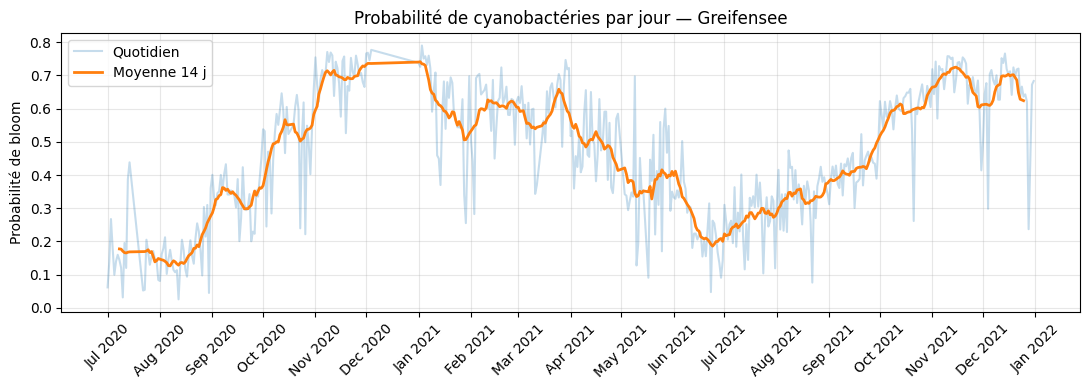

In [11]:
df = df.sort_values("date")

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(df["date"], df["proba_pred"], alpha=0.25, label="Quotidien")
ax.plot(df["date"], df["proba_pred"].rolling(14, center=True).mean(),
        lw=2, label="Moyenne 14 j")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)

ax.set_ylabel("Probabilité de bloom")
ax.set_title("Probabilité de cyanobactéries par jour — Greifensee")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/cyano_per_day.svg")
plt.show()

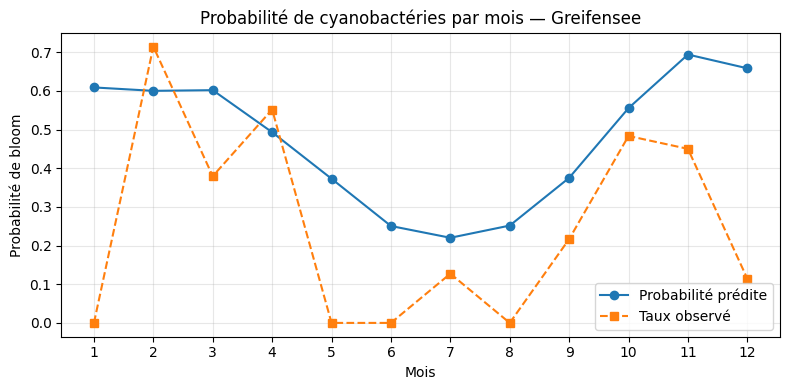

In [16]:
df["proba_pred"] = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]

grp = df.groupby(df["date"].dt.month)
proba_mois = grp["proba_pred"].mean()
taux_obs = grp["target"].mean()

plt.figure(figsize=(8, 4))
plt.plot(proba_mois.index, proba_mois.values, marker="o", label="Probabilité prédite")
plt.plot(taux_obs.index,   taux_obs.values,   marker="s", ls="--", label="Taux observé")
plt.xlabel("Mois")
plt.ylabel("Probabilité de bloom")
plt.title("Probabilité de cyanobactéries par mois — Greifensee")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/actual_vs_predicted.svg")
plt.show()